---
## 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 추가 설명
- 이 노트북은 제공된 3개 NTP ICE Excel 파일을 모두 후보로 비교한 뒤, 모델링 가능성이 가장 높은 데이터셋을 선정한다.
- 선정 이후 RDKit 2D descriptor와 Morgan fingerprint를 함께 계산하여 feature 다양성을 확보한다.

# 기말고사 Template 1 — Data Pipeline

**이름:** ______________ &nbsp; **학번:** ______________ &nbsp;

---

## 채점 기준 반영 내용

| 항목 | 구현 위치 |
|---|---|
| 데이터 분포 파악 및 전처리 | 2~5번 코드 셀: Excel 로딩, 후보 데이터셋 비교, SMILES 정규화, 중복 화합물 처리 |
| Descriptor 계산 | 7번 코드 셀: RDKit 2D descriptor + Morgan fingerprint 계산 |
| 데이터 시각화 자료 | 6번 코드 셀: 후보 데이터 규모, 라벨 비율, 최종 라벨 분포 시각화 |
| 코드 가독성 & 주석 | 각 코드 셀에 한국어 주석 추가 |

## 입력 / 출력
- 입력: `skin_irritation.xlsx`, `eye_irritation.xlsx`, `skin_sensitization.xlsx`
- 출력: `final_dataset_descriptors.csv`, `model_results.csv`, `best_model.joblib`, `figures/*.png`

In [1]:
# 1. 라이브러리 로딩 및 기본 설정
# - pandas: Excel 데이터 처리
# - RDKit: SMILES 정규화, descriptor/fingerprint 계산
# - scikit-learn: 모델 학습 및 평가
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')  # 잘못된 SMILES가 있을 때 RDKit 경고가 너무 많이 출력되는 것을 방지

DATA_DIR = Path('.')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
SALT_REMOVER = SaltRemover()

excel_files = sorted(DATA_DIR.glob('*.xlsx'))
print('확인된 Excel 파일:', [p.name for p in excel_files])

확인된 Excel 파일: ['eye_irritation.xlsx', 'skin_irritation.xlsx', 'skin_sensitization.xlsx']


## 1. 데이터 선정 근거 실험

모델 개발 전에 세 가지 NTP ICE 데이터 파일을 모두 후보로 두고 비교한다. 비교 기준은 다음과 같다.

1. 유효한 SMILES가 있는가
2. 이진 분류 라벨로 변환 가능한 Response가 충분한가
3. 중복 제거 후 고유 화합물 수가 충분한가
4. 양성/음성 라벨 비율이 지나치게 한쪽으로 치우치지 않는가

아래 실험 결과를 근거로 최종 모델링 데이터셋을 자동 선정한다.

In [2]:
# 2. 공통 유틸리티 함수
# NTP ICE 파일마다 Response 표현이 다르므로, 모델링 가능한 이진 라벨만 0/1로 변환한다.
def normalize_binary_label(value):
    """NTP ICE Response 값을 이진 라벨로 변환한다.

    반환값:
    - 1: 독성/자극/감작성 양성
    - 0: 음성 또는 not classified
    - np.nan: 이진 라벨로 해석하기 어려운 값
    """
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    positive_values = {
        'active', 'sensitizer', 'irritant', 'corrosive', 'positive',
        '1', '1a', '1b', '1c', '2', '2a', '2b'
    }
    negative_values = {
        'inactive', 'non-sensitizer', 'non-sensitiser', 'not classified',
        'not classified/non-irritant', '0', '3', '4'
    }

    if text in positive_values:
        return 1
    if text in negative_values:
        return 0
    return np.nan


def clean_smiles(smiles):
    """강의 자료(w5, w6) 방식으로 salt/fragment를 정리한다.

    NTP ICE 데이터에는 salt, counter ion, 여러 fragment가 '.'으로 함께 들어간 SMILES가 있다.
    단일 화합물 descriptor를 계산하려면 salt를 제거하고, 남은 fragment 중 가장 큰 구조를 대표 구조로 둔다.
    """
    if pd.isna(smiles):
        return np.nan

    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return np.nan

    try:
        stripped = SALT_REMOVER.StripMol(mol, dontRemoveEverything=True)
        cleaned = Chem.MolToSmiles(stripped)
    except Exception:
        cleaned = str(smiles).strip()

    # salt 제거 후에도 fragment가 여러 개면 heavy atom 수가 가장 큰 fragment를 active ingredient로 본다.
    fragments = [frag for frag in cleaned.split('.') if frag]
    if len(fragments) > 1:
        fragments = sorted(
            fragments,
            key=lambda smi: Chem.MolFromSmiles(smi).GetNumHeavyAtoms() if Chem.MolFromSmiles(smi) else 0,
            reverse=True,
        )
        cleaned = fragments[0]

    return cleaned


def canonicalize_smiles(smiles):
    """SMILES를 정리한 뒤 RDKit canonical SMILES로 변환한다.

    같은 화합물이 다른 SMILES 문자열로 기록되어도 중복으로 처리할 수 있게 한다.
    RDKit이 파싱하지 못하는 값은 np.nan으로 반환한다.
    """
    cleaned = clean_smiles(smiles)
    if pd.isna(cleaned):
        return np.nan
    mol = Chem.MolFromSmiles(cleaned)
    if mol is None:
        return np.nan
    return Chem.MolToSmiles(mol)


def read_data_sheets(path):
    """Excel 파일에서 실제 관측치가 들어 있는 Data 계열 sheet만 읽는다."""
    xls = pd.ExcelFile(path)
    frames = []
    for sheet_name in xls.sheet_names:
        if sheet_name.lower().startswith('data'):
            df = pd.read_excel(path, sheet_name=sheet_name)
            df['source_file'] = path.name
            df['source_sheet'] = sheet_name
            frames.append(df)
    return frames

In [3]:
# 3. 데이터 후보별 모델링 가능성 평가
# 각 파일/sheet에 대해 화합물만 남기고, 유효 SMILES와 이진 라벨이 있는 행을 집계한다.
candidate_rows = []
raw_frames = []

for path in excel_files:
    for df in read_data_sheets(path):
        raw_frames.append(df)
        work = df.copy()

        # 혼합물은 단일 구조 descriptor 계산이 어렵기 때문에 기본 모델링 후보에서는 제외한다.
        if 'Mixture' in work.columns:
            work = work[work['Mixture'].fillna('Chemical').eq('Chemical')]

        work['label'] = work['Response'].map(normalize_binary_label)
        work['canonical_smiles'] = work['SMILES'].map(canonicalize_smiles)
        valid = work.dropna(subset=['label', 'canonical_smiles']).copy()

        candidate_rows.append({
            'source_file': work['source_file'].iloc[0],
            'source_sheet': work['source_sheet'].iloc[0],
            'raw_rows_after_chemical_filter': len(work),
            'valid_binary_rows': len(valid),
            'unique_chemicals': valid['canonical_smiles'].nunique(),
            'positive_rows': int(valid['label'].sum()),
            'negative_rows': int((valid['label'] == 0).sum()),
            'positive_ratio': valid['label'].mean() if len(valid) else np.nan,
            'endpoint_count': valid['Endpoint'].nunique() if 'Endpoint' in valid.columns else np.nan,
        })

candidate_summary = pd.DataFrame(candidate_rows)
candidate_summary['balance_score'] = 1 - (candidate_summary['positive_ratio'] - 0.5).abs() * 2
candidate_summary['selection_score'] = (
    candidate_summary['unique_chemicals'] * 0.70
    + candidate_summary['valid_binary_rows'] * 0.20
    + candidate_summary['balance_score'].fillna(0) * 100 * 0.10
)
candidate_summary = candidate_summary.sort_values('selection_score', ascending=False).reset_index(drop=True)

print('데이터 선정 실험 결과')
display(candidate_summary)

데이터 선정 실험 결과


,source_file,source_sheet,raw_rows_after_chemical_filter,valid_binary_rows,unique_chemicals,positive_rows,negative_rows,positive_ratio,endpoint_count,balance_score,selection_score
0,skin_sensitization.xlsx,Data_invivo,11011,5404,1138,1045,4359,0.193375,6,0.386751,1881.267506
1,skin_sensitization.xlsx,Data_invitro,8837,3178,233,1805,1373,0.567967,11,0.864065,807.340654
2,skin_irritation.xlsx,Data_invitro,5614,2351,216,1346,1005,0.572522,12,0.854955,629.949553
3,eye_irritation.xlsx,Data,1062,629,171,367,262,0.583466,7,0.833068,253.830684
4,skin_irritation.xlsx,Data_invivo,259,155,97,43,112,0.277419,3,0.554839,104.448387


In [4]:
# 4. 선정된 데이터셋 로딩 및 중복 화합물 처리
# selection_score는 고유 화합물 수를 가장 중요하게 보고, 라벨 수와 클래스 균형을 보조 기준으로 반영한다.
selected = candidate_summary.iloc[0]
SELECTED_FILE = selected['source_file']
SELECTED_SHEET = selected['source_sheet']
print(f"선정 데이터셋: {SELECTED_FILE} / {SELECTED_SHEET}")

selected_df = pd.read_excel(DATA_DIR / SELECTED_FILE, sheet_name=SELECTED_SHEET)
selected_df = selected_df[selected_df['Mixture'].fillna('Chemical').eq('Chemical')].copy()
selected_df['label'] = selected_df['Response'].map(normalize_binary_label)
selected_df['canonical_smiles'] = selected_df['SMILES'].map(canonicalize_smiles)
selected_df = selected_df.dropna(subset=['label', 'canonical_smiles']).copy()
selected_df['label'] = selected_df['label'].astype(int)

# 같은 화합물이 여러 시험/문헌에 반복 등장할 수 있으므로 canonical SMILES 기준으로 다수결 라벨을 만든다.
# 같은 화합물에서 양성/음성이 충돌하는 경우도 있으므로 conflict_rate를 계산해 데이터 품질 지표로 남긴다.
def aggregate_one_chemical(group):
    label_mean = group['label'].mean()
    majority_label = int(label_mean >= 0.5)
    conflict_rate = group['label'].nunique() > 1
    return pd.Series({
        'Chemical_Name': group['Chemical_Name'].dropna().iloc[0] if group['Chemical_Name'].notna().any() else np.nan,
        'SMILES': group.name,
        'label': majority_label,
        'n_records': len(group),
        'positive_fraction': label_mean,
        'label_conflict': bool(conflict_rate),
        'source_file': SELECTED_FILE,
        'source_sheet': SELECTED_SHEET,
    })

model_df = (
    selected_df
    .groupby('canonical_smiles', as_index=False)
    .apply(aggregate_one_chemical, include_groups=False)
    .reset_index(drop=True)
)

print('중복 제거 전 행 수:', len(selected_df))
print('중복 제거 후 고유 화합물 수:', len(model_df))
print('라벨 충돌 화합물 수:', int(model_df['label_conflict'].sum()))
print('최종 라벨 분포')
display(model_df['label'].value_counts().rename(index={0: 'negative', 1: 'positive'}))
display(model_df.head())

선정 데이터셋: skin_sensitization.xlsx / Data_invivo


중복 제거 전 행 수: 5404
중복 제거 후 고유 화합물 수: 1138
라벨 충돌 화합물 수: 216
최종 라벨 분포


label
negative    996
positive    142
Name: count, dtype: int64

,canonical_smiles,Chemical_Name,SMILES,label,n_records,positive_fraction,label_conflict,source_file,source_sheet
0,BrC=Cc1ccccc1,(2-Bromovinyl)benzene,BrC=Cc1ccccc1,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo
1,C#CC(C)(O)CCC=C(C)C,Dehydrolinalool,C#CC(C)(O)CCC=C(C)C,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo
2,C#CC1(OC(C)=O)CCCCC1,"Cyclohexanol, 1-ethynyl-, 1-acetate",C#CC1(OC(C)=O)CCCCC1,0,6,0.0,False,skin_sensitization.xlsx,Data_invivo
3,C#CC1(OC(C)=O)CCCCC1C(C)CC,"Cyclohexanol, 1-ethynyl-2-(1-methylpropyl)-, 1...",C#CC1(OC(C)=O)CCCCC1C(C)CC,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo
4,C=C(C)C(=O)OC,Methyl methacrylate,C=C(C)C(=O)OC,0,5,0.4,True,skin_sensitization.xlsx,Data_invivo


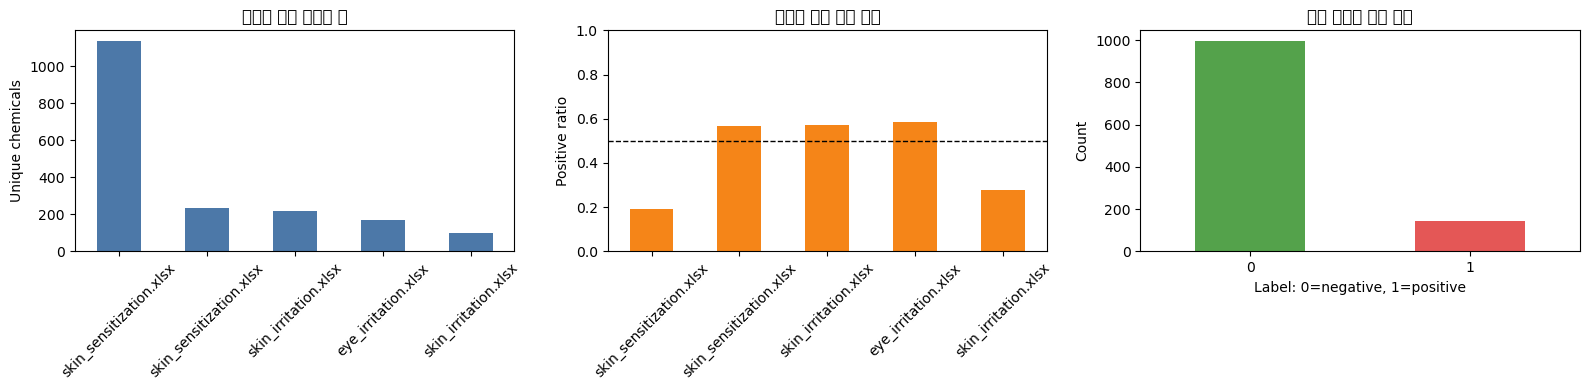

In [5]:
# 5. 데이터 분포 및 선정 근거 시각화
# 채점 기준의 데이터 시각화 자료로 저장한다.
plt.style.use('default')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

candidate_summary.plot(
    x='source_file', y='unique_chemicals', kind='bar', ax=axes[0], legend=False, color='#4c78a8'
)
axes[0].set_title('후보별 고유 화합물 수')
axes[0].set_xlabel('')
axes[0].set_ylabel('Unique chemicals')
axes[0].tick_params(axis='x', rotation=45)

candidate_summary.plot(
    x='source_file', y='positive_ratio', kind='bar', ax=axes[1], legend=False, color='#f58518'
)
axes[1].axhline(0.5, color='black', linewidth=1, linestyle='--')
axes[1].set_ylim(0, 1)
axes[1].set_title('후보별 양성 라벨 비율')
axes[1].set_xlabel('')
axes[1].set_ylabel('Positive ratio')
axes[1].tick_params(axis='x', rotation=45)

model_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color=['#54a24b', '#e45756']
)
axes[2].set_title('최종 데이터 라벨 분포')
axes[2].set_xlabel('Label: 0=negative, 1=positive')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'data_selection_and_label_distribution.png', dpi=150)
plt.show()

## 2. Descriptor 계산

최종 모델 입력 feature는 두 계열을 함께 만든다.

- RDKit 2D descriptor: 분자량, LogP, TPSA, HBD/HBA, ring count 등 해석 가능한 물성 중심
- Morgan fingerprint: 부분 구조 패턴을 bit vector로 표현하여 구조적 다양성 반영

두 feature 계열을 따로 학습해 보고, 결합했을 때 성능이 좋아지는지도 비교한다.

In [6]:
# 6. RDKit descriptor 및 Morgan fingerprint 계산 함수
DESCRIPTOR_FUNCS = {
    'MolWt': Descriptors.MolWt,
    'MolLogP': Descriptors.MolLogP,
    'TPSA': rdMolDescriptors.CalcTPSA,
    'NumHDonors': rdMolDescriptors.CalcNumHBD,
    'NumHAcceptors': rdMolDescriptors.CalcNumHBA,
    'NumRotatableBonds': rdMolDescriptors.CalcNumRotatableBonds,
    'RingCount': rdMolDescriptors.CalcNumRings,
    'HeavyAtomCount': Descriptors.HeavyAtomCount,
    'FractionCSP3': rdMolDescriptors.CalcFractionCSP3,
    'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings,
}


def calculate_rdkit_descriptors(smiles):
    """단일 SMILES에서 해석 가능한 RDKit 2D descriptor를 계산한다."""
    mol = Chem.MolFromSmiles(smiles)
    values = {}
    for name, func in DESCRIPTOR_FUNCS.items():
        try:
            values[name] = func(mol)
        except Exception:
            values[name] = np.nan
    return values


def calculate_morgan_fingerprint(smiles, radius=2, n_bits=1024):
    """Morgan fingerprint를 0/1 numpy 배열로 변환한다."""
    mol = Chem.MolFromSmiles(smiles)
    bitvect = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(bitvect, arr)
    return arr

# Descriptor dataframe 생성
descriptor_df = pd.DataFrame([
    calculate_rdkit_descriptors(smiles) for smiles in model_df['SMILES']
])

# Fingerprint dataframe 생성
fp_bits = np.vstack([
    calculate_morgan_fingerprint(smiles, radius=2, n_bits=1024) for smiles in model_df['SMILES']
])
fp_df = pd.DataFrame(fp_bits, columns=[f'ECFP4_{i}' for i in range(fp_bits.shape[1])])

final_dataset = pd.concat([
    model_df[['Chemical_Name', 'SMILES', 'label', 'n_records', 'positive_fraction', 'label_conflict']],
    descriptor_df,
    fp_df,
], axis=1)

final_dataset.to_csv('final_dataset_descriptors.csv', index=False)
print('저장 완료: final_dataset_descriptors.csv')
print('최종 데이터 shape:', final_dataset.shape)
display(final_dataset.head())

저장 완료: final_dataset_descriptors.csv
최종 데이터 shape: (1138, 1040)


,Chemical_Name,SMILES,label,n_records,positive_fraction,label_conflict,MolWt,MolLogP,TPSA,NumHDonors,...,ECFP4_1014,ECFP4_1015,ECFP4_1016,ECFP4_1017,ECFP4_1018,ECFP4_1019,ECFP4_1020,ECFP4_1021,ECFP4_1022,ECFP4_1023
0,(2-Bromovinyl)benzene,BrC=Cc1ccccc1,0,3,0.0,False,183.048,3.0522,0.00,0,...,0,0,0,0,0,0,0,0,0,0
1,Dehydrolinalool,C#CC(C)(O)CCC=C(C)C,0,3,0.0,False,152.237,2.1170,20.23,1,...,0,0,0,1,0,0,0,0,0,0
2,"Cyclohexanol, 1-ethynyl-, 1-acetate",C#CC1(OC(C)=O)CCCCC1,0,6,0.0,False,166.220,1.8856,26.30,0,...,0,0,0,1,0,0,0,0,0,0
3,"Cyclohexanol, 1-ethynyl-2-(1-methylpropyl)-, 1...",C#CC1(OC(C)=O)CCCCC1C(C)CC,0,3,0.0,False,222.328,3.1578,26.30,0,...,0,0,0,1,0,1,0,0,0,0
4,Methyl methacrylate,C=C(C)C(=O)OC,0,5,0.4,True,100.117,0.7355,26.30,0,...,0,0,0,1,0,0,0,0,1,0


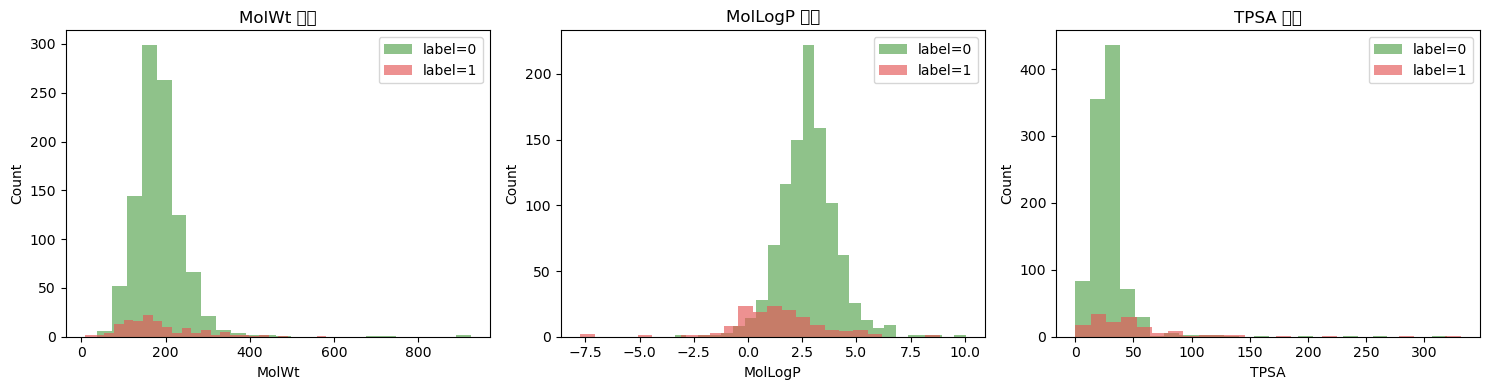

In [7]:
# 7. Descriptor 분포 시각화
# 분자량, LogP, TPSA는 화학 descriptor 해석에 자주 쓰이는 대표 변수다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['MolWt', 'MolLogP', 'TPSA']):
    for label, color in [(0, '#54a24b'), (1, '#e45756')]:
        ax.hist(
            final_dataset.loc[final_dataset['label'] == label, col],
            bins=25,
            alpha=0.65,
            label=f'label={label}',
            color=color,
        )
    ax.set_title(f'{col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'descriptor_distributions.png', dpi=150)
plt.show()

## 2-1. 강의 자료 기반 descriptor 전처리 보강

`w5-1_descriptor_preprocessing`, `w9-1_feature_selection_and_svm`, `w10-1_tree_models_and_ensemble`에서 반복한 전처리 기준을 추가한다.

- 결측이 많은 descriptor 제거
- 표준편차가 너무 작은 descriptor 제거
- 상관계수가 매우 높은 descriptor 중복 제거
- SelectKBest로 상위 descriptor를 고르는 실험 수행

In [8]:
# 8. 강의 자료 방식의 descriptor 전처리
# fingerprint는 0/1 bit이므로 그대로 두고, 연속형 RDKit 2D descriptor에 대해 전처리 기준을 기록한다.
descriptor_cols = list(DESCRIPTOR_FUNCS.keys())
X_desc_raw = final_dataset[descriptor_cols].copy()
y_all = final_dataset['label'].astype(int)

preprocess_log = []

# 1) 결측 비율이 높은 descriptor 제거
missing_ratio = X_desc_raw.isna().mean()
missing_keep_cols = missing_ratio[missing_ratio <= 0.20].index.tolist()
preprocess_log.append({
    'step': 'missing_ratio <= 0.20',
    'n_features_before': X_desc_raw.shape[1],
    'n_features_after': len(missing_keep_cols),
    'removed_features': ', '.join(sorted(set(X_desc_raw.columns) - set(missing_keep_cols))),
})
X_desc_pre = X_desc_raw[missing_keep_cols]

# 2) 거의 변하지 않는 descriptor 제거. 강의에서는 std >= 0.01 기준을 사용했다.
std_values = X_desc_pre.std(numeric_only=True)
variance_keep_cols = std_values[std_values >= 0.01].index.tolist()
preprocess_log.append({
    'step': 'std >= 0.01',
    'n_features_before': X_desc_pre.shape[1],
    'n_features_after': len(variance_keep_cols),
    'removed_features': ', '.join(sorted(set(X_desc_pre.columns) - set(variance_keep_cols))),
})
X_desc_pre = X_desc_pre[variance_keep_cols]

# 3) 상관계수가 높은 descriptor는 같은 정보를 반복할 수 있어 하나만 남긴다.
def remove_high_corr_columns(df, threshold=0.95):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    return [col for col in df.columns if col not in drop_cols], drop_cols

preprocessed_descriptor_cols, corr_drop_cols = remove_high_corr_columns(X_desc_pre, threshold=0.95)
preprocess_log.append({
    'step': 'correlation <= 0.95',
    'n_features_before': X_desc_pre.shape[1],
    'n_features_after': len(preprocessed_descriptor_cols),
    'removed_features': ', '.join(corr_drop_cols),
})

descriptor_preprocessing_summary = pd.DataFrame(preprocess_log)
descriptor_preprocessing_summary.to_csv('descriptor_preprocessing_summary.csv', index=False)

print('저장 완료: descriptor_preprocessing_summary.csv')
print('전처리 후 descriptor:', preprocessed_descriptor_cols)
display(descriptor_preprocessing_summary)

저장 완료: descriptor_preprocessing_summary.csv
전처리 후 descriptor: ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'RingCount', 'FractionCSP3', 'NumAromaticRings']


,step,n_features_before,n_features_after,removed_features
0,missing_ratio <= 0.20,10,10,
1,std >= 0.01,10,10,
2,correlation <= 0.95,10,9,HeavyAtomCount


In [9]:
# 9. SelectKBest 기반 feature 수(K) 선정 실험
# 강의 자료(w9-1)처럼 K 후보를 바꿔가며 Logistic Regression CV 성능을 비교한다.
k_candidates = [k for k in [3, 5, 7, 10, 15, 20] if k <= len(preprocessed_descriptor_cols)]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kbest_rows = []

for k in k_candidates:
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=f_classif, k=k)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    scores = cross_validate(
        pipe,
        final_dataset[preprocessed_descriptor_cols],
        y_all,
        cv=cv,
        scoring=['balanced_accuracy', 'roc_auc', 'f1'],
        n_jobs=-1,
    )
    kbest_rows.append({
        'k': k,
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'f1_mean': scores['test_f1'].mean(),
    })

kbest_results = pd.DataFrame(kbest_rows).sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)
kbest_results.to_csv('kbest_descriptor_results.csv', index=False)
best_k = int(kbest_results.iloc[0]['k'])

selector_for_names = SelectKBest(score_func=f_classif, k=best_k)
selector_for_names.fit(
    SimpleImputer(strategy='median').fit_transform(final_dataset[preprocessed_descriptor_cols]),
    y_all,
)
selected_kbest_descriptor_cols = list(np.array(preprocessed_descriptor_cols)[selector_for_names.get_support()])

print('저장 완료: kbest_descriptor_results.csv')
print('Best K:', best_k)
print('선택된 descriptor:', selected_kbest_descriptor_cols)
display(kbest_results)

저장 완료: kbest_descriptor_results.csv
Best K: 7
선택된 descriptor: [np.str_('MolLogP'), np.str_('TPSA'), np.str_('NumHDonors'), np.str_('NumHAcceptors'), np.str_('NumRotatableBonds'), np.str_('FractionCSP3'), np.str_('NumAromaticRings')]


,k,balanced_accuracy_mean,roc_auc_mean,f1_mean
0,7,0.763395,0.833667,0.451159
1,5,0.753542,0.832982,0.437160
2,3,0.714459,0.793427,0.400365


In [10]:
# 10. 강의 자료 기반 모델 보강 실험: Logistic Regression, SVM, MLP
# SVM과 MLP는 스케일에 민감하므로 StandardScaler를 반드시 포함한다.
lecture_model_specs = {
    'logreg_kbest': LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
    'svm_rbf_kbest': SVC(C=1.0, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'mlp_kbest': MLPClassifier(hidden_layer_sizes=(best_k,), max_iter=2000, random_state=RANDOM_STATE),
}

lecture_rows = []
X_kbest = final_dataset[selected_kbest_descriptor_cols]

for model_name, model in lecture_model_specs.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])
    scores = cross_validate(
        pipe,
        X_kbest,
        y_all,
        cv=cv,
        scoring=['balanced_accuracy', 'roc_auc', 'f1'],
        n_jobs=-1,
    )
    lecture_rows.append({
        'model': model_name,
        'features': 'SelectKBest RDKit 2D descriptors',
        'k': best_k,
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'f1_mean': scores['test_f1'].mean(),
    })

lecture_model_results = pd.DataFrame(lecture_rows).sort_values('roc_auc_mean', ascending=False)
lecture_model_results.to_csv('lecture_style_model_results.csv', index=False)
print('저장 완료: lecture_style_model_results.csv')
display(lecture_model_results)

저장 완료: lecture_style_model_results.csv


,model,features,k,balanced_accuracy_mean,roc_auc_mean,f1_mean
1,svm_rbf_kbest,SelectKBest RDKit 2D descriptors,7,0.798200,0.860937,0.522435
2,mlp_kbest,SelectKBest RDKit 2D descriptors,7,0.645502,0.844242,0.430031
0,logreg_kbest,SelectKBest RDKit 2D descriptors,7,0.763395,0.833667,0.451159


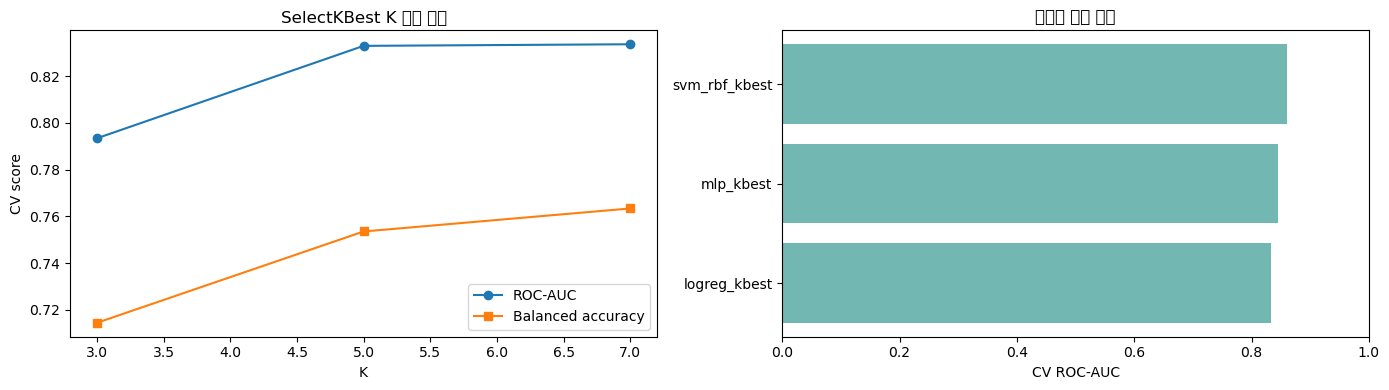

In [11]:
# 11. K 선택 실험 및 강의식 모델 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_k = kbest_results.sort_values('k')
axes[0].plot(plot_k['k'], plot_k['roc_auc_mean'], marker='o', label='ROC-AUC')
axes[0].plot(plot_k['k'], plot_k['balanced_accuracy_mean'], marker='s', label='Balanced accuracy')
axes[0].set_xlabel('K')
axes[0].set_ylabel('CV score')
axes[0].set_title('SelectKBest K 선택 실험')
axes[0].legend()

plot_models = lecture_model_results.sort_values('roc_auc_mean')
axes[1].barh(plot_models['model'], plot_models['roc_auc_mean'], color='#72b7b2')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('CV ROC-AUC')
axes[1].set_title('강의식 모델 비교')

plt.tight_layout()
plt.savefig(FIG_DIR / 'lecture_style_feature_selection.png', dpi=150)
plt.show()

## 3. 모델 개발 및 feature 선정 실험

동일한 train/test split에서 다음 조합을 비교한다.

- `rdkit_2d`: 해석 가능한 2D descriptor만 사용
- `fingerprint`: Morgan fingerprint만 사용
- `combined`: 2D descriptor와 fingerprint를 모두 사용

모델도 Logistic Regression, Random Forest, Gradient Boosting을 비교하여 가장 높은 ROC-AUC 조합을 최종 모델로 저장한다.

In [12]:
# 8. 모델 학습/평가용 데이터 구성
metadata_cols = ['Chemical_Name', 'SMILES', 'label', 'n_records', 'positive_fraction', 'label_conflict']
descriptor_cols = list(DESCRIPTOR_FUNCS.keys())
fingerprint_cols = [c for c in final_dataset.columns if c.startswith('ECFP4_')]

y = final_dataset['label'].astype(int)
feature_sets = {
    'rdkit_2d': descriptor_cols,
    'rdkit_2d_preprocessed': preprocessed_descriptor_cols,
    'rdkit_2d_kbest': selected_kbest_descriptor_cols,
    'fingerprint': fingerprint_cols,
    'combined': descriptor_cols + fingerprint_cols,
}

X_train_full, X_test_full, y_train, y_test = train_test_split(
    final_dataset.drop(columns=['label']),
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('학습 데이터:', X_train_full.shape, '테스트 데이터:', X_test_full.shape)
print('학습 라벨 비율:', y_train.mean().round(3), '테스트 라벨 비율:', y_test.mean().round(3))

학습 데이터: (910, 1039) 테스트 데이터: (228, 1039)
학습 라벨 비율: 0.125 테스트 라벨 비율: 0.123


In [13]:
# 9. 모델 후보 비교
# class_weight='balanced'는 음성/양성 비율이 불균형할 때 소수 클래스를 더 반영하기 위해 사용한다.
def make_pipeline(model_name):
    if model_name == 'logistic_regression':
        model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    if model_name == 'random_forest':
        model = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
    if model_name == 'gradient_boosting':
        model = GradientBoostingClassifier(random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
    raise ValueError(model_name)

model_names = ['logistic_regression', 'random_forest', 'gradient_boosting']
results = []
best = {'roc_auc': -np.inf, 'pipeline': None, 'feature_set': None, 'model_name': None, 'columns': None}

for feature_set_name, cols in feature_sets.items():
    X_train = X_train_full[cols]
    X_test = X_test_full[cols]

    for model_name in model_names:
        pipe = make_pipeline(model_name)
        pipe.fit(X_train, y_train)

        pred = pipe.predict(X_test)
        if hasattr(pipe.named_steps['model'], 'predict_proba'):
            score = pipe.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, score)
        else:
            roc_auc = np.nan

        row = {
            'feature_set': feature_set_name,
            'model': model_name,
            'n_features': len(cols),
            'accuracy': accuracy_score(y_test, pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, pred),
            'f1': f1_score(y_test, pred),
            'roc_auc': roc_auc,
        }
        results.append(row)

        if roc_auc > best['roc_auc']:
            best.update({
                'roc_auc': roc_auc,
                'pipeline': pipe,
                'feature_set': feature_set_name,
                'model_name': model_name,
                'columns': cols,
            })

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
results_df.to_csv('model_results.csv', index=False)
print('저장 완료: model_results.csv')
display(results_df)
print('최종 선택 모델:', best['feature_set'], '/', best['model_name'], '/', 'ROC-AUC=', round(best['roc_auc'], 3))

저장 완료: model_results.csv


,feature_set,model,n_features,accuracy,balanced_accuracy,f1,roc_auc
0,fingerprint,random_forest,1024,0.929825,0.791071,0.680000,0.946429
1,combined,random_forest,1034,0.934211,0.793571,0.693878,0.941786
2,combined,gradient_boosting,1034,0.921053,0.724643,0.590909,0.933393
3,fingerprint,gradient_boosting,1024,0.903509,0.683929,0.500000,0.907679
4,rdkit_2d_kbest,gradient_boosting,7,0.894737,0.663571,0.454545,0.894286
5,combined,logistic_regression,1034,0.942982,0.860000,0.763636,0.894107
6,fingerprint,logistic_regression,1024,0.916667,0.814286,0.666667,0.893750
7,rdkit_2d,gradient_boosting,10,0.912281,0.704286,0.545455,0.889554
8,rdkit_2d_preprocessed,gradient_boosting,9,0.907895,0.701786,0.533333,0.885000
9,rdkit_2d_preprocessed,random_forest,9,0.916667,0.722143,0.577778,0.876786


최종 선택 모델: fingerprint / random_forest / ROC-AUC= 0.946


In [14]:
# 10. 최종 모델 상세 평가 및 저장
best_X_test = X_test_full[best['columns']]
best_pred = best['pipeline'].predict(best_X_test)
best_score = best['pipeline'].predict_proba(best_X_test)[:, 1]

print('Confusion matrix')
print(confusion_matrix(y_test, best_pred))
print()
print('Classification report')
print(classification_report(y_test, best_pred, target_names=['negative', 'positive']))
print('ROC-AUC:', round(roc_auc_score(y_test, best_score), 4))

# 모델 재사용에 필요한 feature column 정보도 함께 저장한다.
model_artifact = {
    'pipeline': best['pipeline'],
    'feature_columns': best['columns'],
    'feature_set': best['feature_set'],
    'model_name': best['model_name'],
    'selected_source_file': SELECTED_FILE,
    'selected_source_sheet': SELECTED_SHEET,
}
joblib.dump(model_artifact, 'best_model.joblib')
print('저장 완료: best_model.joblib')

# 강의 자료(w11)처럼 저장한 모델을 바로 다시 불러와 같은 전처리/feature로 예측되는지 확인한다.
loaded_artifact = joblib.load('best_model.joblib')
loaded_pred = loaded_artifact['pipeline'].predict(X_test_full[loaded_artifact['feature_columns']].head(5))
print('저장 모델 재로드 예측 예시:', loaded_pred.tolist())

Confusion matrix
[[195   5]
 [ 11  17]]

Classification report
              precision    recall  f1-score   support

    negative       0.95      0.97      0.96       200
    positive       0.77      0.61      0.68        28

    accuracy                           0.93       228
   macro avg       0.86      0.79      0.82       228
weighted avg       0.93      0.93      0.93       228

ROC-AUC: 0.9464
저장 완료: best_model.joblib


저장 모델 재로드 예측 예시: [0, 0, 0, 0, 0]


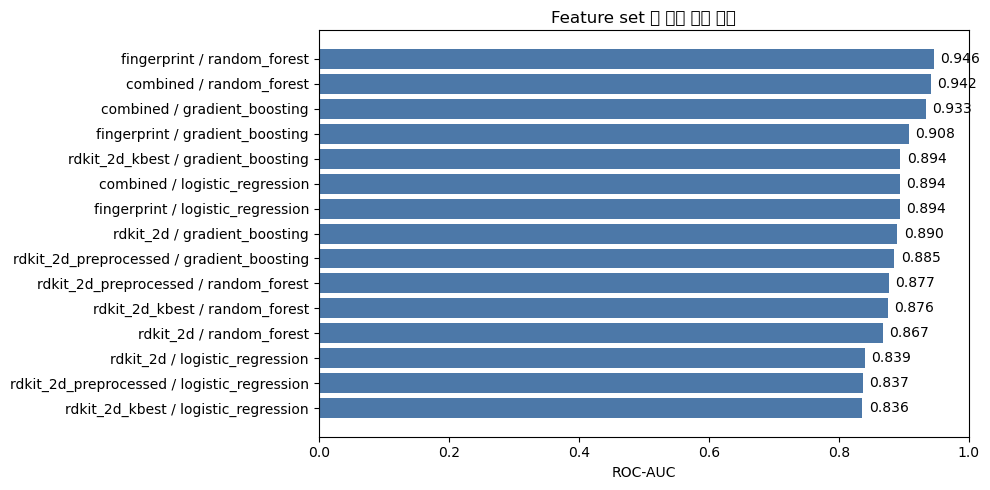

In [15]:
# 11. 모델 비교 결과 시각화
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.sort_values('roc_auc')
labels = plot_df['feature_set'] + ' / ' + plot_df['model']
ax.barh(labels, plot_df['roc_auc'], color='#4c78a8')
ax.set_xlim(0, 1)
ax.set_xlabel('ROC-AUC')
ax.set_title('Feature set 및 모델 후보 비교')
for i, value in enumerate(plot_df['roc_auc']):
    ax.text(value + 0.01, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150)
plt.show()

## 결론 작성 예시

아래 내용은 실행 결과를 확인한 뒤 수치만 맞춰 제출용으로 정리하면 된다.

- 세 데이터 후보를 비교한 결과, 중복 제거 후 고유 화합물 수와 이진 라벨 확보량이 가장 큰 데이터셋을 최종 모델링 대상으로 선정하였다.
- 혼합물은 단일 SMILES descriptor 계산이 어렵기 때문에 제외했고, 동일 화합물의 반복 기록은 canonical SMILES 기준으로 다수결 집계하였다.
- RDKit 2D descriptor는 해석 가능성을, Morgan fingerprint는 부분 구조 정보를 반영하기 위해 함께 사용하였다.
- `descriptor_preprocessing_summary.csv`와 `kbest_descriptor_results.csv`를 통해 강의 자료에서 다룬 descriptor 전처리 및 SelectKBest 선정 근거를 별도로 남겼다.
- `lecture_style_model_results.csv`에서 Logistic Regression, SVM, MLP를 같은 feature 조건으로 비교하였다.
- `model_results.csv`의 ROC-AUC, balanced accuracy, F1을 기준으로 최종 모델을 선택하였다.